In [205]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [206]:
# import packages
import seaborn as sns
import itertools
from sklearn.preprocessing import Imputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from pandas import read_csv
%matplotlib inline

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [207]:
diab = pd.read_csv('diabetes.csv')

In [208]:
# Eye ball the imported dataset

In [209]:
diab.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [210]:
diab.describe().transpose()  

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [211]:
diab.isnull().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

In [212]:
diab.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [213]:
print(diab.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### Check dimension of dataset

In [214]:
diab.shape

(768, 9)

In [215]:
diab.size

6912

In [216]:
diab.ndim

2

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

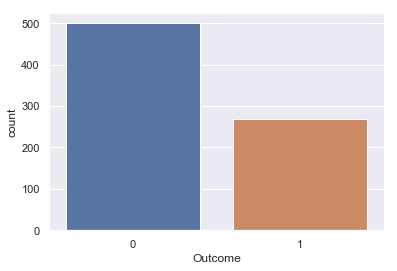

In [217]:
import seaborn as sns
sns.countplot(diab['Outcome'],label="Count")

In [218]:
print(diab.groupby('Outcome').size())

Outcome
0    500
1    268
dtype: int64


### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [219]:
# Check data types and info of dataset

In [220]:
diab.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [221]:
diab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Check data distribution using summary statistics and provide your findings(2 Marks)

In [222]:
#Get the count of zeros in each of the columns
# We can see for Glucose, BloodPressure, SkinThickness, Insulin, BMI the minimum is 0 
# these has to be replaced with the mean of the fields not equal to zero.
print((diab[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum())

Pregnancies      111
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [223]:
#Mark zero values as missing or NaN
diab[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = diab[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0, np.NaN)

In [224]:
print(diab.isnull().sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [225]:
diab.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5.0,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10.0,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8.0,125.0,96.0,NaN,NaN,NaN,0.232,54,1


In [226]:
# Call the fillna() function with the imputation strategy
diab.fillna(diab.mean(), inplace=True)

In [227]:
print (diab.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [228]:
diab.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000000,148.0,72.000000,35.00000,155.548223,33.600000,0.627,50,1
1,1.000000,85.0,66.000000,29.00000,155.548223,26.600000,0.351,31,0
2,8.000000,183.0,64.000000,29.15342,155.548223,23.300000,0.672,32,1
3,1.000000,89.0,66.000000,23.00000,94.000000,28.100000,0.167,21,0
4,4.494673,137.0,40.000000,35.00000,168.000000,43.100000,2.288,33,1
5,5.000000,116.0,74.000000,29.15342,155.548223,25.600000,0.201,30,0
6,3.000000,78.0,50.000000,32.00000,88.000000,31.000000,0.248,26,1
7,10.000000,115.0,72.405184,29.15342,155.548223,35.300000,0.134,29,0
8,2.000000,197.0,70.000000,45.00000,543.000000,30.500000,0.158,53,1
9,8.000000,125.0,96.000000,29.15342,155.548223,32.457464,0.232,54,1


In [229]:
diab.mean()

Pregnancies                   4.494673
Glucose                     121.686763
BloodPressure                72.405184
SkinThickness                29.153420
Insulin                     155.548223
BMI                          32.457464
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64

In [230]:
diab.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.494673,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,2.975395,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,4.494673,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C:\Users\sugan\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\Users\sugan\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


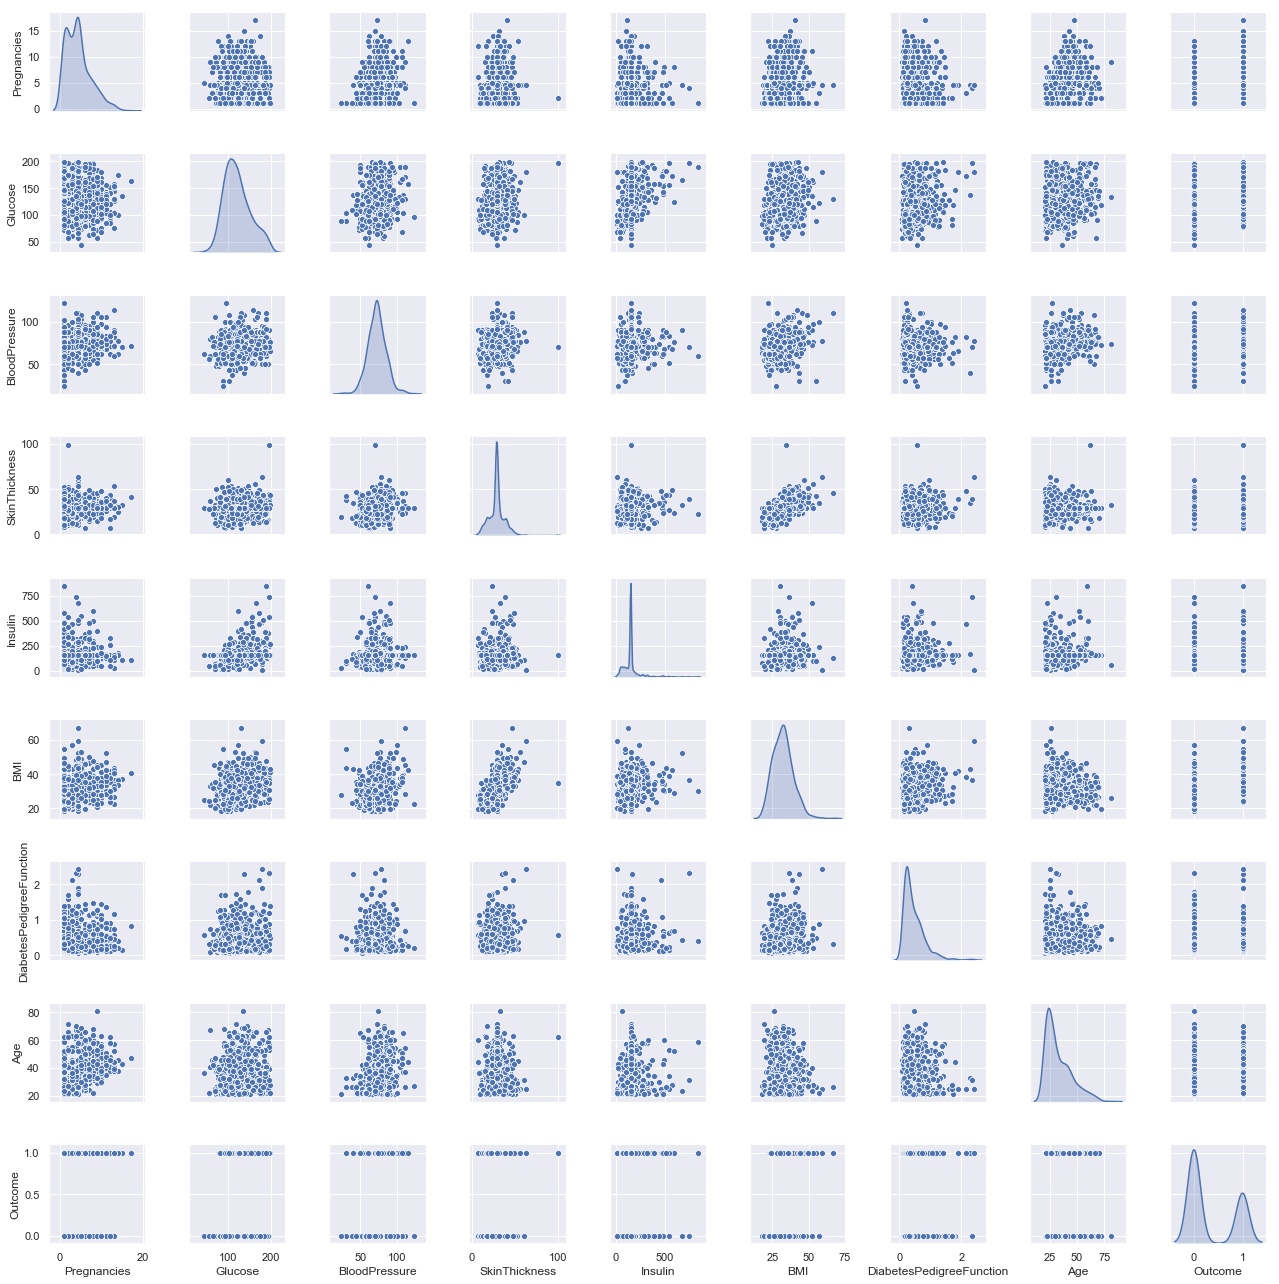

In [231]:
#scatterplot
sns.set()
sns.pairplot(diab, size = 2.0,diag_kind='kde')
plt.show()

### Do correlation analysis and bivariate viualization with Insights(1 Marks)

In [232]:
diab_table = diab.corr(method = 'pearson')

In [233]:
# g = sns.heatmap(diab.corr(),cmap="Blues",annot=False)
diab_table.corr(method='pearson').style.format("{:.2}").background_gradient(cmap=plt.get_cmap('coolwarm'), axis=1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.0,-0.23,0.18,-0.27,-0.35,-0.37,-0.46,0.67,-0.044
Glucose,-0.23,1.0,-0.15,-0.2,0.44,-0.12,-0.18,-0.043,0.5
BloodPressure,0.18,-0.15,1.0,-0.059,-0.35,0.044,-0.47,0.25,-0.21
SkinThickness,-0.27,-0.2,-0.059,1.0,-0.15,0.68,-0.18,-0.36,-0.1
Insulin,-0.35,0.44,-0.35,-0.15,1.0,-0.15,-0.14,-0.23,0.01
BMI,-0.37,-0.12,0.044,0.68,-0.15,1.0,-0.09,-0.56,0.059
DiabetesPedigreeFunction,-0.46,-0.18,-0.47,-0.18,-0.14,-0.09,1.0,-0.43,-0.094
Age,0.67,-0.043,0.25,-0.36,-0.23,-0.56,-0.43,1.0,-0.072
Outcome,-0.044,0.5,-0.21,-0.1,0.01,0.059,-0.094,-0.072,1.0


Outcome
0    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
1    [[AxesSubplot(0.125,0.670278;0.215278x0.209722...
dtype: object

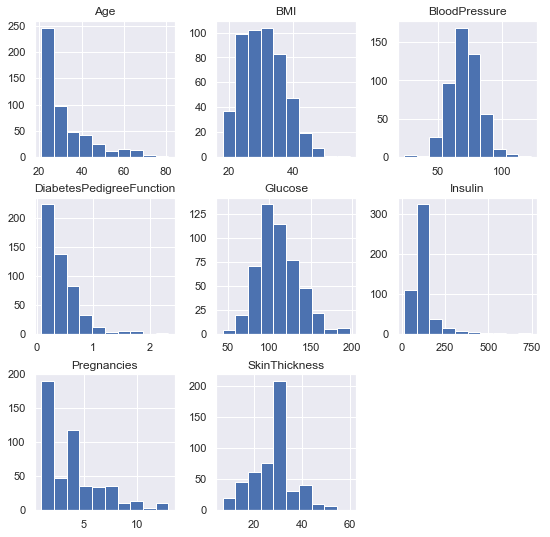

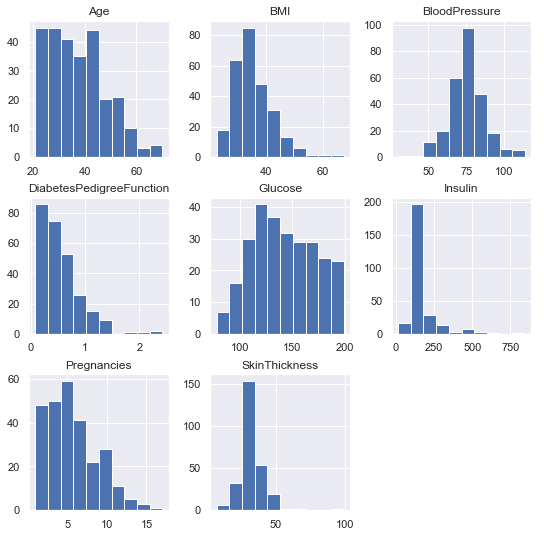

In [234]:
diab.groupby('Outcome').hist(figsize=(9, 9))

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [235]:
# import needed 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.svm import SVC
from math import *
from sklearn.metrics import classification_report
%matplotlib inline

In [236]:
X_train, X_test, y_train, y_test = train_test_split(diab.loc[:, diab.columns != 'Outcome'], diab['Outcome'], stratify=diab['Outcome'], random_state=66)

In [237]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
612,7.0,168.0,88.0,42.00000,321.000000,38.2,0.787,40
557,8.0,110.0,76.0,29.15342,155.548223,27.8,0.237,58
26,7.0,147.0,76.0,29.15342,155.548223,39.4,0.257,43
70,2.0,100.0,66.0,20.00000,90.000000,32.9,0.867,28
73,4.0,129.0,86.0,20.00000,270.000000,35.1,0.231,23


### Train Support Vector Machine Model(1 Marks)

In [238]:
svc = SVC()
svc.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(svc.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(svc.score(X_test, y_test)))

Accuracy on training set: 1.00
Accuracy on test set: 0.65


C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [239]:
# your insights

# The model overfits quite substantially, with a perfect score on the training set and only 65% accuracy on the test set.

### Scale the data points using MinMaxScaler ( 1 Marks)

In [240]:
# SVM requires all the features to vary on a similar scale. 
# We will need to re-scale our data that all the features are approximately on the same scale
from sklearn.preprocessing import MinMaxScaler

In [241]:
scaler = MinMaxScaler()

In [242]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)
C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:323: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)


In [243]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
612,7.0,168.0,88.0,42.00000,321.000000,38.2,0.787,40
557,8.0,110.0,76.0,29.15342,155.548223,27.8,0.237,58
26,7.0,147.0,76.0,29.15342,155.548223,39.4,0.257,43
70,2.0,100.0,66.0,20.00000,90.000000,32.9,0.867,28
73,4.0,129.0,86.0,20.00000,270.000000,35.1,0.231,23


### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [244]:
svc = SVC()
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.2f}".format(svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.2f}".format(svc.score(X_test_scaled, y_test)))

Accuracy on training set: 0.78
Accuracy on test set: 0.80


C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [245]:
# scaling of data did have impact on the accuracy of training data set.  

#we can try increasing either C or gamma to fit a more complex model.

In [257]:
svc = SVC(C=100)
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
    svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

Accuracy on training set: 0.786
Accuracy on test set: 0.776


C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


### Try improving the model accuracy using C=1000 (1 Marks)

In [247]:
svc = SVC(C=1000)
svc.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
    svc.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc.score(X_test_scaled, y_test)))

C:\Users\sugan\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


Accuracy on training set: 0.800
Accuracy on test set: 0.802


### Here, increasing C allows us to improve the model, resulting in 80.2% accuracy on test data.
### Let's try to explore different Kernel and C (Bonus for practice)

In [248]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [249]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [250]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [251]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [252]:
gs.best_estimator_

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='linear', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [253]:
gs.best_score_ 

0.7743055555555556